# Chapter 5

### Imports

In [1]:
import os

import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations




from scipy.spatial.distance import euclidean
from collections import deque
from sklearn.metrics import r2_score
from itertools import combinations

from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

from scipy.optimize import curve_fit
from scipy import stats


import utils.util_functions as util_f
import utils.graph_functions as graph_f
import utils.curve_fitting as fit_curve

import importlib
importlib.reload(util_f)
importlib.reload(graph_f)

<module 'utils.graph_functions' from '/Users/c23103021/Documents/Chapter5_BehaviouralAnalysis/Insect_Trajectory_Dataset/Chapter_5/utils/graph_functions.py'>

### 5.3.2 Data Preprocessing

In [27]:
#read data
data_path = '../Pollination_Analysis_Summary'
df = pd.read_csv(os.path.join(data_path, 'flower_visits.csv'))
df = df.sort_values(by=['track', 'clock_time']) # sort values (probably not necesary)

qtile = df['time'].quantile(0.98) # calculate 98% quantile for visitation duration
print(f"98 percent of visitation duration values is below {qtile:.3}")
print(f"all values more than 20 seconds removed (justification in Chapter)")

df = df.sort_values(by=['track', 'clock_time'])
df['visit_sequence'] = df.groupby('track').cumcount() + 1 


98 percent of visitation duration values is below 19.9
all values more than 20 seconds removed (justification in Chapter)


In [28]:
## Thresholds
MAXIMUM_THRESHOLD = 20 #All data for visitation duration > 20 seconds removed (later)

In [29]:
# Function that calculates: time since last visit, last visit duration and last species
df_features = util_f.preceding_visit_feature_extraction(df.copy()) 

# Merges together two dataframes
merged_df = df.merge(df_features, left_index=True, right_index=True) 
merged_df['time_since_last_minutes'] = merged_df['time_since_last_visit'].apply(lambda x: x/60) # time last visit in mimnutes
merged_df['clock_time_minutes'] = merged_df['clock_time'].map(lambda x: x/60)# clock time in muinutes
merged_df['flower_visit_num'] = merged_df.groupby('flower_code').cumcount() + 1 # creates unique flower code for each flower :) 

# Position of current flower within bout (+1 starts with 1 as first)
#merged_df = merged_df.sort_values(by=['track', 'clock_time'])

#merged_df['visit_sequence'] = merged_df.groupby('track').cumcount() + 1 
# number of flowers visited within bout
merged_df['max_seq'] = merged_df.groupby('track')['visit_sequence'].transform('max') 

## Removes all visitattions where visitation duration < Maximum threshold
merged_df = merged_df.query("time <= @MAXIMUM_THRESHOLD").copy() 

#### Calculating threshold to segment visitation interactions

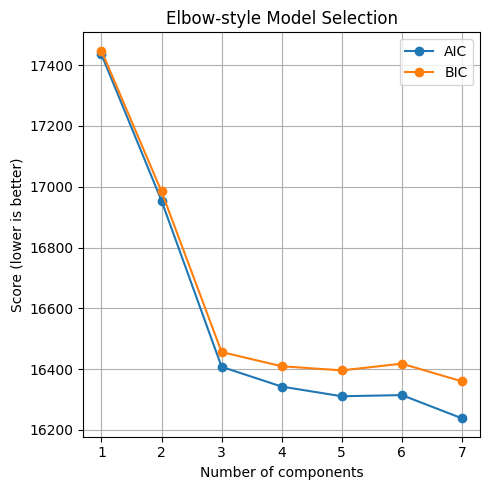

<Figure size 640x480 with 0 Axes>

In [30]:
# SUCCESFUL_THRESHOLD SELECTION
#By clustering with GMM, we select a time threshold to segment 'short' from 'long' visitations
#Below we use the elbow method to select the number of clusters
#For this analysis only using honeybees as dominant class. (can't determine succesful for other as species different
times = merged_df.loc[merged_df['species'] == 'honeybee']['time'].values #time = visitation duration
data = times.reshape(-1, 1) # ensure right shape

n_components_range = range(1, 8)#number of componenets for GMM (testing best)
bics = []
aics = []
models = []

for k in n_components_range: # apply GMM to each number of clusters to test
    gmm = GaussianMixture(n_components=k, random_state=0)
    gmm.fit(data)
    bics.append(gmm.bic(data))
    aics.append(gmm.aic(data))
    models.append(gmm)

fig, axes = plt.subplots(1, 1, figsize=(5, 5))
axes.plot(n_components_range, aics, marker='o', label='AIC')
axes.plot(n_components_range, bics, marker='o', label='BIC')
axes.set_title("Elbow-style Model Selection")
axes.set_xlabel("Number of components")
axes.set_ylabel("Score (lower is better)")
axes.legend()
axes.grid(True)
plt.tight_layout()
plt.show()
plt.savefig('plot_outputs/GMM_elbow.jpg')


BIC for 3 components: 16456.23
Cluster means: [ 1.15888943  5.26463326 10.64787878]
Cluster std devs: [0.73005366 2.22422493 3.76559907]
Cluster weights: [0.28572765 0.59466523 0.11960712]
Approximate thresholds: 2.30 and 9.87 seconds


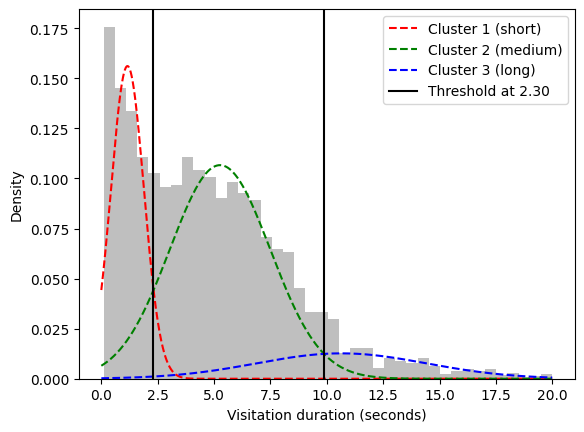

In [31]:
#Observationally, Elbow is at 3! Hence, we use this cluster (n_components)
gmm = GaussianMixture(n_components=3, random_state=0) 
gmm.fit(data)
plt = graph_f.gmm_plot(gmm, data, times)
plt.savefig('plot_outputs/GMM_threshold.jpg')

In [32]:
# We use overlap of clusters to select the 'short visitation duration here ('longest' vistation duration is ignored')
#NB assumption of succesful (is actually just 'LONG' Interaction
#Threshold is at 2.3
SUCCESFUL_THRESHOLD = 2.3
merged_df['succesful'] = merged_df['time'].apply(lambda x: x>SUCCESFUL_THRESHOLD) # succesful visit: time> succes time

### 5.3.4. Determining factors influencing visitation duration

For this Section We Used A separate R script as opposed to python due to its superiority with statistics (python did not have an effecetive and easy to implement nested random effects implementation). Pre sorting and scaling was done in Python

In [33]:
from sklearn.preprocessing import StandardScaler

# Model and variable preparation
model_df = merged_df.dropna(subset=['time_since_last_minutes']).copy()
model_df = model_df.loc[model_df['species'] == 'honeybee'].copy()

predictors = ['time_since_last_minutes', 'clock_time', 'max_seq', 
              'visit_sequence', 'last_visit_time']

# Scale the predictors
scaler = StandardScaler()
model_df[predictors] = scaler.fit_transform(model_df[predictors]) #z-score scaling

model_df.to_csv('model_df.csv')
model_df[predictors].corr() # Pearson correlation 

,time_since_last_minutes,clock_time,max_seq,visit_sequence,last_visit_time
time_since_last_minutes,1.000000,0.062839,0.079210,-0.014837,0.008778
clock_time,0.062839,1.000000,-0.133445,-0.100396,-0.096621
max_seq,0.079210,-0.133445,1.000000,0.711508,0.073961
visit_sequence,-0.014837,-0.100396,0.711508,1.000000,0.045661
last_visit_time,0.008778,-0.096621,0.073961,0.045661,1.000000


LMM_Implementation (in R)

library(lme4)
library(lmerTest)


df <- read.csv("model_df.csv")


predictors <- c("time_since_last_minutes", "clock_time", "max_seq", "visit_sequence", "last_visit_time")

predictor_seq <- paste(predictors, collapse = " + ")

formula <- as.formula(
  paste("time ~", predictor_seq, "+ (1 | data_point/flower_code)")
)

model <- lmer(formula, data = df)


print(summary(model))

print(confint(model))

pvals <- summary(model)$coefficients[, "Pr(>|t|)"]

pvals_corrected <- p.adjust(pvals, method = "bonferroni")


results <- data.frame(
  Estimate = fixef(model),
  p_value = pvals,
  p_value_bonf = pvals_corrected
)

print(results)

write.csv(
  results,
  "results/lmm_results.csv",
  row.names = TRUE
)

cat("\nDONE: model complete\n")

GAM_Implementation (in R)


library(mgcv)

df <- read.csv("model_df.csv")

model <- gam( time ~ s(time_since_last_minutes, k = 15) + s(clock_time, k = 15) + s(max_seq, k = 10) + s(visit_sequence, k = 10) + s(last_visit_time, k = 15) +

#### random effects (hierarchical structure)
s(data_point, bs = "re") +
s(flower_code, bs = "re"),

data = df, method = "REML" )

summary(model)

gam.check(model)

par(mfrow = c(2,2)) plot(model, pages = 1, shade = TRUE)

gam_summary <- summary(model)

parametric_table <- gam_summarys.table

print(parametric_table) print(smooth_table)

write.csv( parametric_table, "results/gam_parametric_results.csv", row.names = TRUE )

write.csv( smooth_table, "results/gam_smooth_results.csv", row.names = TRUE )

cat("\nDONE: Fixed GAM model complete\n")

In [34]:
R_implementation = pd.read_csv('results/lmm_results.csv')
R_implementation

,Unnamed: 0,Estimate,Std_Error,t_value,p_value,p_value_bonf
0,(Intercept),4.474647,0.119435,37.465004,2.665230e-09,1.599138e-08
1,time_since_last_minutes,1.206309,0.059829,20.162653,2.382977e-84,1.429786e-83
2,clock_time,-0.099403,0.058893,-1.687870,9.154329e-02,5.492597e-01
3,max_seq,0.769915,0.083698,9.198740,6.691782e-20,4.015069e-19
4,visit_sequence,-0.637439,0.081319,-7.838768,6.339969e-15,3.803982e-14
5,last_visit_time,-0.005447,0.058352,-0.093353,9.256291e-01,1.000000e+00


In [35]:
gam_R_implementation_s = pd.read_csv('results/gam_smooth_results.csv')
gam_R_implementation_r = pd.read_csv('results/gam_parametric_results.csv')
gam_R_implementation_s 

,Unnamed: 0,edf,Ref.df,F,p-value
0,s(time_since_last_minutes),6.401403,7.908773,79.784974,0.000000
1,s(clock_time),1.001726,1.003446,2.690752,0.100903
2,s(max_seq),2.275295,2.849850,28.054056,0.000000
3,s(visit_sequence),1.793944,2.257010,18.654842,0.000000
4,s(last_visit_time),1.004167,1.008320,6.009859,0.014072
5,s(data_point),0.794375,1.000000,4.269662,0.027347
6,s(flower_code),0.013656,1.000000,0.014325,0.323568


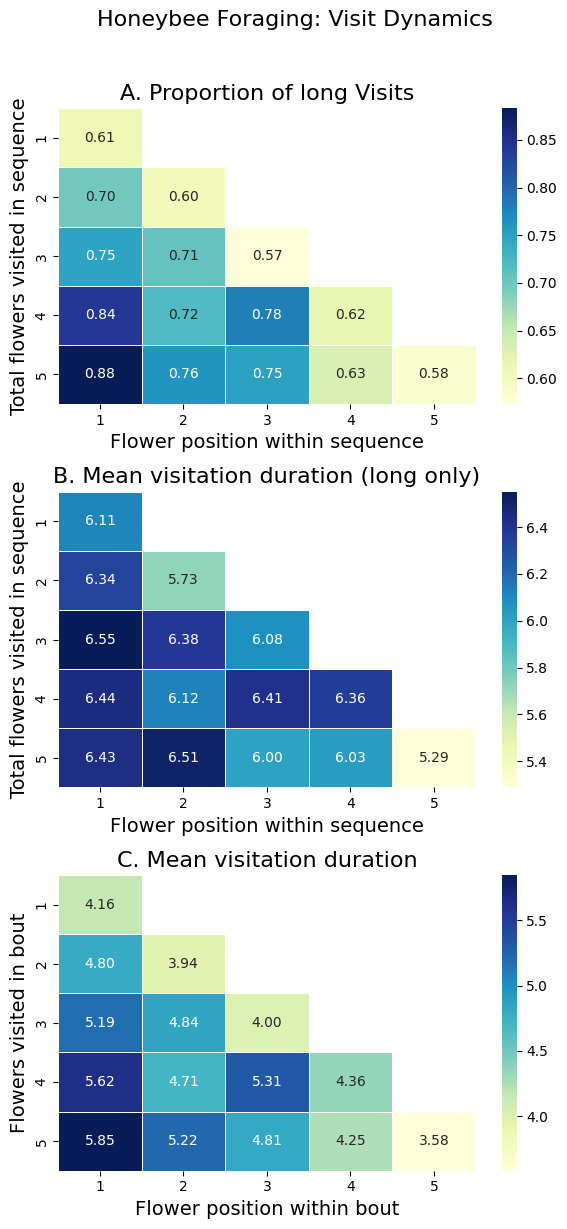

In [36]:
#Plotting visitation duration with respect to bout position and maximum (heatmap)
fig, axes = plt.subplots(3, 1, figsize=(6, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)
f = 14
f2 = 16

#Proportion long visits
clean1 = merged_df.loc[(merged_df['species'] == 'honeybee') & (merged_df['max_seq']<6)]
data1 = clean1.groupby(['max_seq', 'visit_sequence'])['succesful'].agg(['mean', 'count']).reset_index()
pivot1 = data1.pivot(index='max_seq', columns='visit_sequence', values='mean')
sns.heatmap(pivot1, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5, ax=axes[0])
axes[0].set_title("A. Proportion of long Visits", fontsize=f2)
axes[0].set_xlabel("Flower position within sequence", fontsize = f)
axes[0].set_ylabel("Total flowers visited in sequence", fontsize = f)

# Successful visit durations (t > 2.3)
clean2 = merged_df.loc[(merged_df['time'] > SUCCESFUL_THRESHOLD) & (merged_df['species'] == 'honeybee')& (merged_df['max_seq']<6)]
data2 = clean2.groupby(['max_seq', 'visit_sequence'])['time'].agg(['mean', 'count']).reset_index()
pivot2 = data2.pivot(index='max_seq', columns='visit_sequence', values='mean')
sns.heatmap(pivot2, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5, ax=axes[1])
axes[1].set_title("B. Mean visitation duration (long only)", fontsize=f2)
axes[1].set_xlabel("Flower position within sequence", fontsize=f)
axes[1].set_ylabel("Total flowers visited in sequence", fontsize=f)

# 3. All visits
clean3 = merged_df.loc[(merged_df['species'] == 'honeybee')& (merged_df['max_seq']<6)] # Keep to five or less sequences due to data amounts
data3 = clean3.groupby(['max_seq', 'visit_sequence'])['time'].agg(['mean', 'count']).reset_index()
pivot3 = data3.pivot(index='max_seq', columns='visit_sequence', values='mean')
sns.heatmap(pivot3, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5, ax=axes[2])
axes[2].set_title("C. Mean visitation duration", fontsize=f2)
axes[2].set_xlabel("Flower position within bout", fontsize=f)
axes[2].set_ylabel("Flowers visited in bout", fontsize=f)


plt.suptitle("Honeybee Foraging: Visit Dynamics", fontsize=16, y=1.02)
plt.savefig('plot_outputs/foraging_time_dynamics.jpg')
plt.tight_layout()
plt.show()

### 5.3.5. Grouping flowers with similar visitation dynamics

In [12]:
import warnings
warnings.filterwarnings("ignore")

flower_dataDir =  '../Extracted_Tracks/Flower_Positions_CSV'
flower_dataframe = util_f.extract_flower_dataframes(flower_dataDir)
flower_dataframe = flower_dataframe.set_index('flower_code')
code_to_rad = flower_dataframe['radius'].to_dict() #extract dictionary: flower code to radius

#prepare data (join in flower count) intergrating 'flower data with data'
grouped = merged_df.groupby(by='flower_code')[['succesful', 'time']].agg(['mean', 'sum', 'count']).reset_index()
#below basically strips the grouped python (multilayered columns -- and produces one. 
grouped.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in grouped.columns.values]
grouped['location'] = grouped['flower_code_'].apply(lambda x: int(str(x)[:3])) #this section represents the filming location
grouped['flower_code_'] = grouped['flower_code_'].apply(lambda x: str(int(x)))
grouped['radius'] = grouped['flower_code_'].map(code_to_rad)
grouped = grouped.loc[grouped['succesful_count'] > 3] # only do for more than 3 visitations!

In [13]:
## prepare data / apply PCA
on_vars = ['succesful_mean', 'succesful_count', 'time_mean']
X = grouped[on_vars].copy()
scaler = StandardScaler() # Data standardisation
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2) # PCA: Reducing data to 2 dimensions
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=grouped.index)
# Print explained variance ratio
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", sum(pca.explained_variance_ratio_))

Explained variance ratio: [0.58828133 0.3197003 ]
Total explained variance: 0.9079816214574815


Calculating metrics for k = 2 3 4 5 6 7 8 9 10 


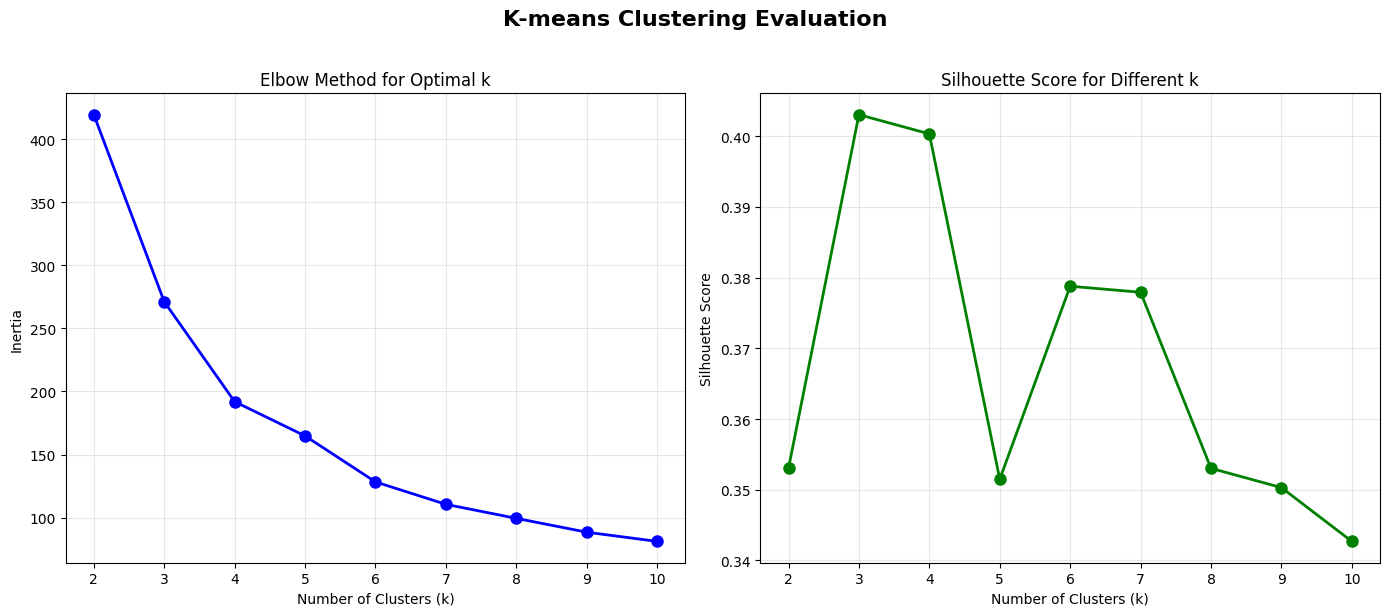

In [14]:
plt = graph_f.plot_elbow_and_silhouette_side_by_side(X_pca)
plt.savefig('plot_outputs/k_means_selection')


Clustering Evaluation Metrics for k = 3
Inertia: 271.150340837567
Silhouette Score: 0.4030391862642103


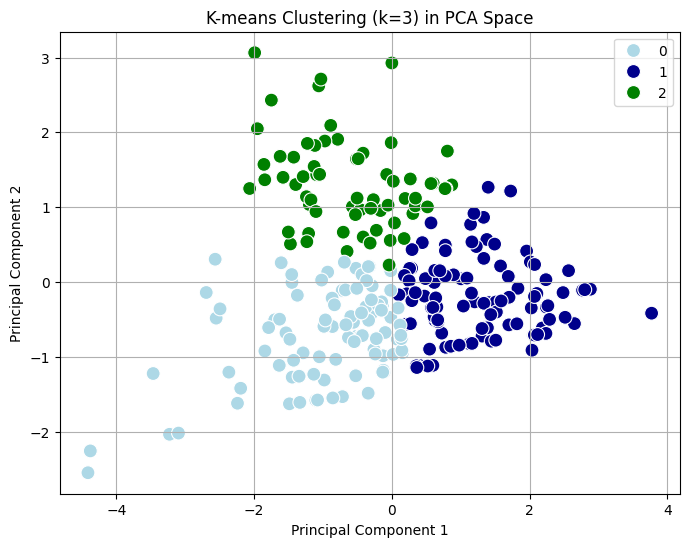

In [15]:
# 3 clusters chosen by elbow method and silhouete score optimisation (primarily optimisation)
optimal_k = 3  # selected by silhouette score
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_pca)
pca_df['Cluster'] = clusters
grouped = grouped.merge(pca_df[['Cluster']], left_index=True, right_index=True, how='left') # add to grouped dataframe
#Cluster metrics
print("\nClustering Evaluation Metrics for k =", optimal_k)
print("Inertia:", kmeans.inertia_)
print("Silhouette Score:", silhouette_score(X_pca, clusters))
#Plot for pcs and cluster
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette=['lightblue', 'darkblue', 'green'], s=100)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-means Clustering (k={}) in PCA Space'.format(optimal_k))
plt.legend()
plt.grid(True)
plt.show()

In [16]:
## Create summary for clusters
count_dict = grouped['Cluster'].value_counts().to_dict()
grouped_summary = grouped.groupby('Cluster')[['succesful_mean', 'time_mean', 'succesful_count', 'radius']].mean()
grouped_summary = grouped_summary.reset_index()
grouped_summary['count'] = grouped_summary['Cluster'].map(count_dict)
grouped_summary

,Cluster,succesful_mean,time_mean,succesful_count,radius,count
0,0,0.531918,3.835439,9.684783,32.725275,92
1,1,0.820564,6.163211,9.000000,34.285714,101
2,2,0.682041,4.398382,22.272727,35.666667,66


In [17]:
# map cluster alignments to origonal dataset
fc_to_cluster = grouped.set_index('flower_code_')['Cluster'].to_dict()
merged_df['Cluster'] = merged_df['flower_code'].apply(
    lambda x: fc_to_cluster.get(str(int(x))) if pd.notna(x) else np.nan #convert to cluster value
)

### 5.3.6. Assessing the impact of the time since the last floral visit and the success of subsequent visits

In [18]:
mdf = merged_df.copy()
cleaned = mdf.loc[mdf['species'] == 'honeybee']
cleaned['time_bin'] = pd.cut(cleaned['time_since_last_minutes'], bins=range(0, 30, 4), right=False)
cleaned['under_2_sec'] = cleaned['time'].map(lambda x: x < 2.3)
summary = (
    cleaned
    .groupby(by='time_bin')['under_2_sec']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={
        'mean': 'proportion_under_2_seconds',
        'count': 'n_visits'
    })
)

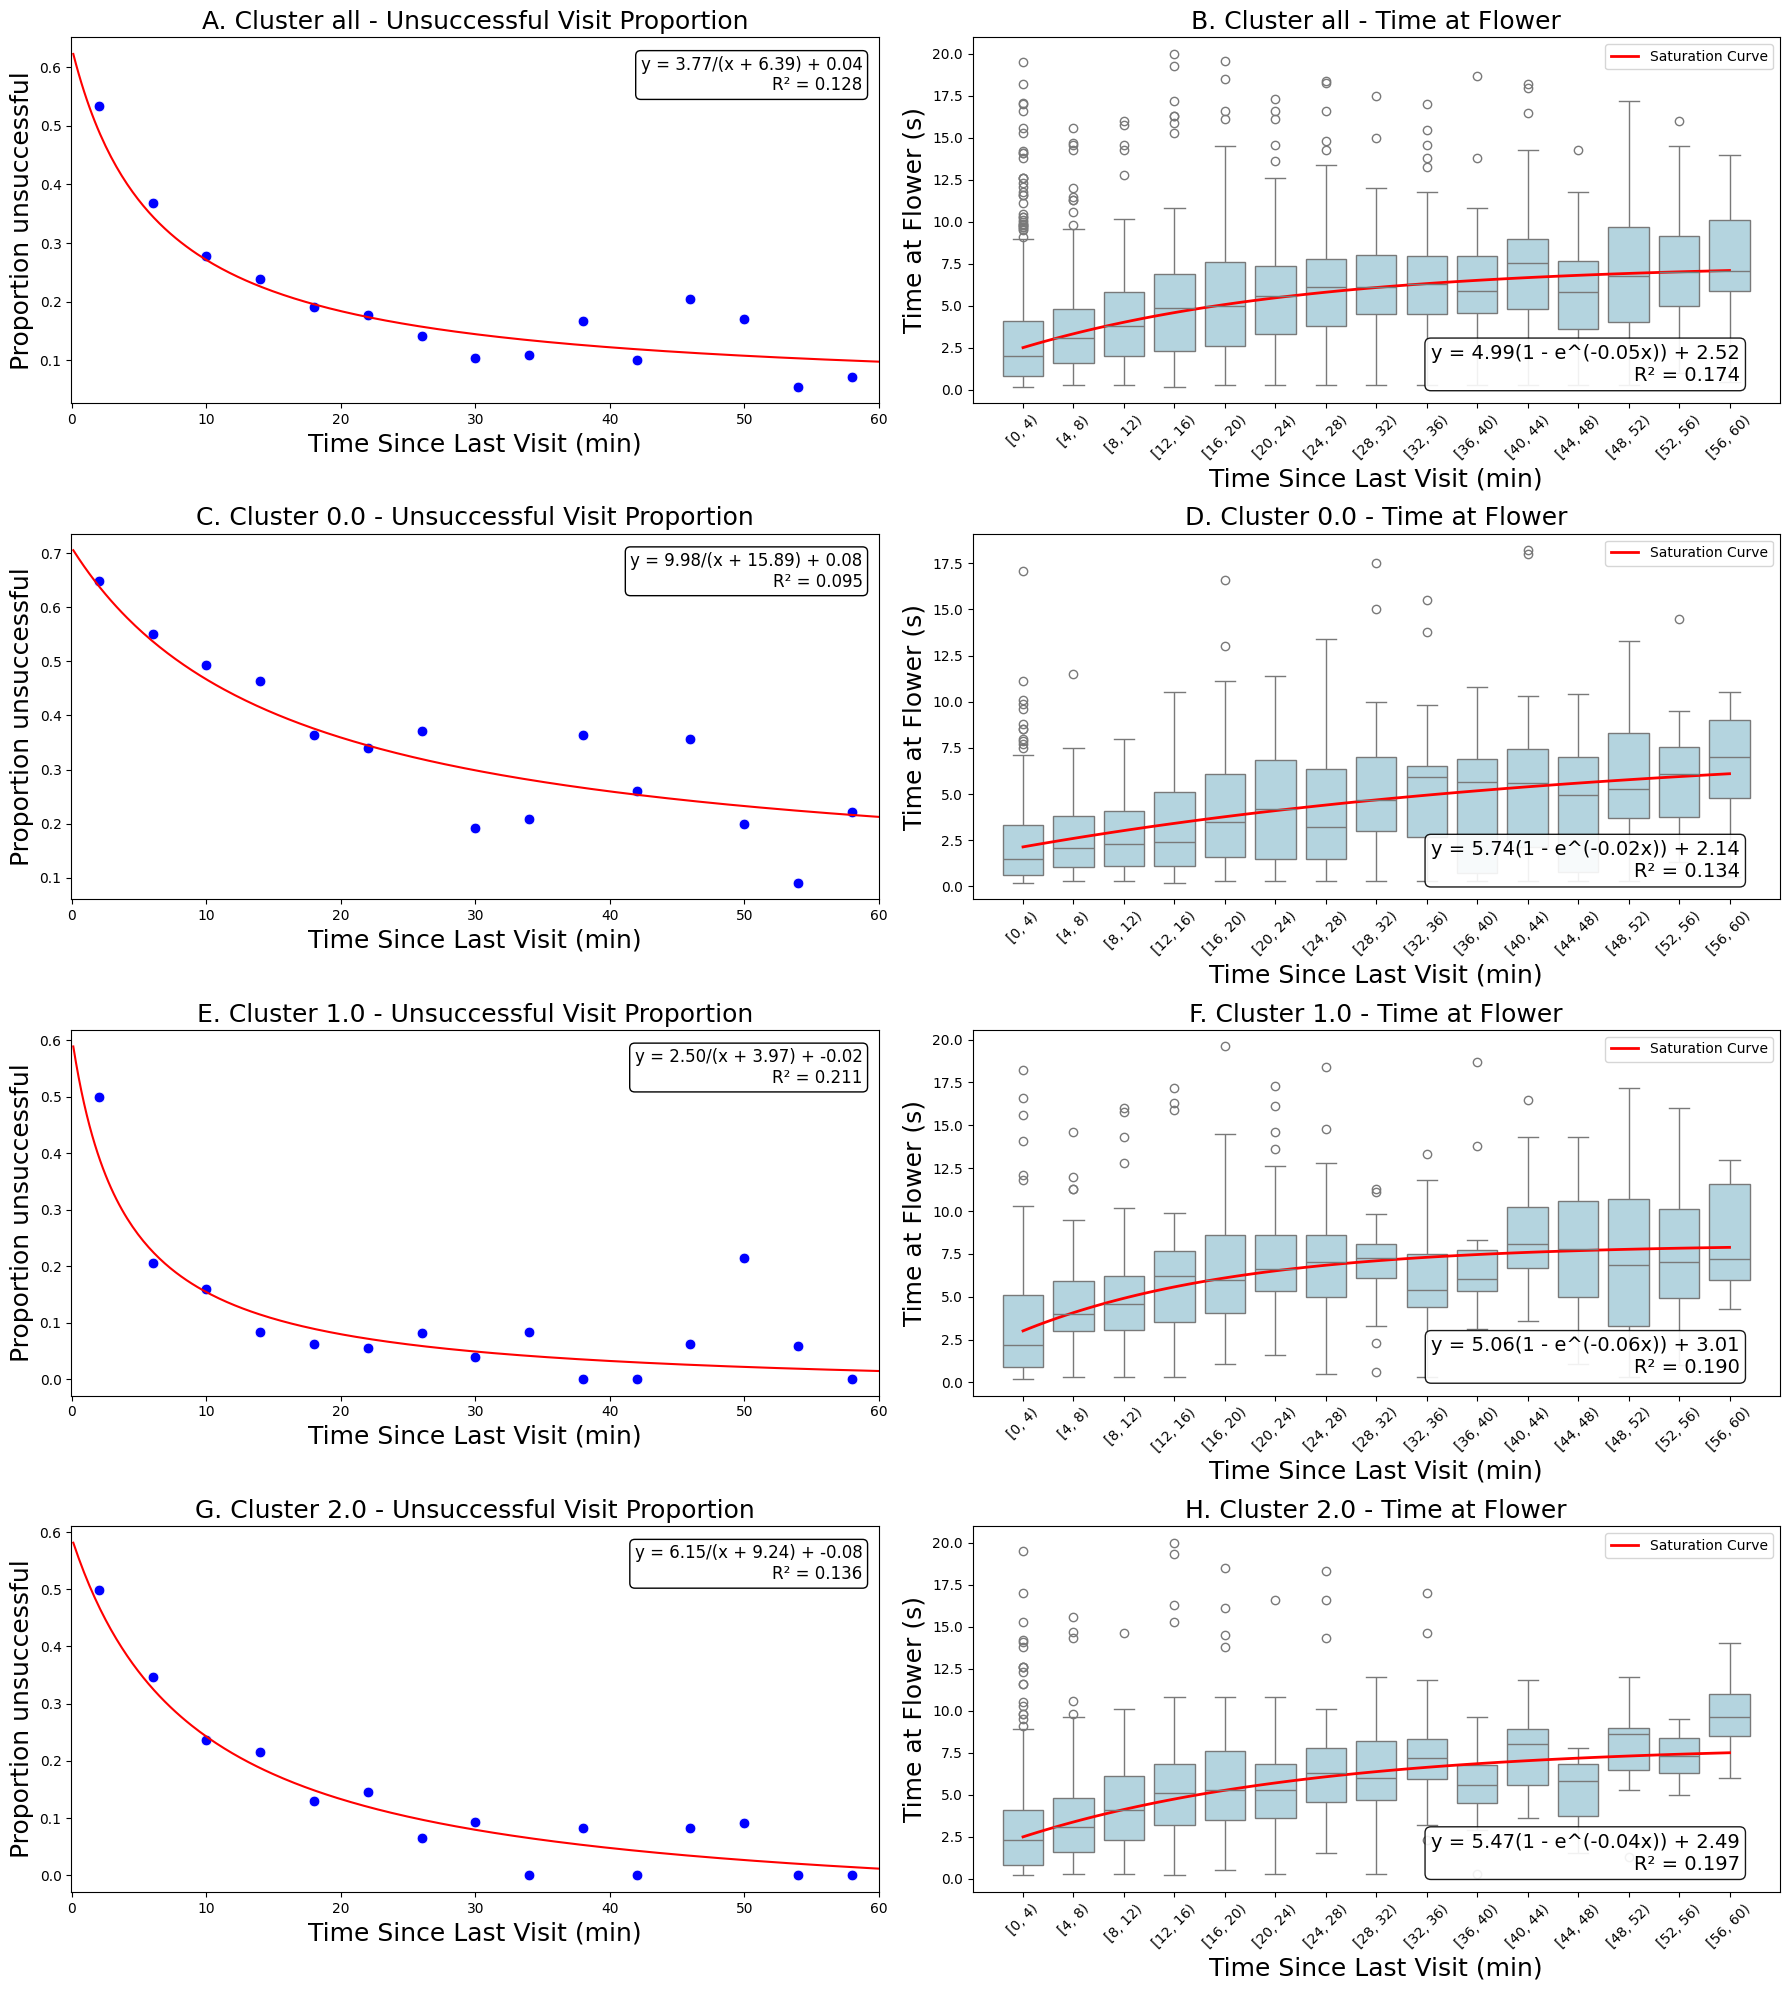

In [19]:
#Here we plot both time since last visit vs visit duration AND binned proportion 'succesful' with time since last visit
#We do this for all clusters calculated in the cluster section

max_graph =60
val = 'time_since_last_minutes'
unique_clusters = sorted(merged_df['Cluster'].dropna().unique())
n_clusters = len(unique_clusters)
results_saturation = []
results_inverse = []
#prepare plots / plot settings
labelsize = 12
title_label = 18
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 20), sharex=False)

combined_data = []

for row_idx, cluster_id in enumerate(['all'] + unique_clusters ): # Goes through all unique clusters
    #AND all which is all date 
    # Prepare axes
    ax_left = axes[row_idx, 0]
    ax_right = axes[row_idx, 1]

    # Select data (filters - if cluster all then all data, else select a clustere
    # NB only honeybee data.
    if cluster_id == 'all':
        mdf = merged_df[
            (merged_df['species'] == 'honeybee') &
            (merged_df[val] < max_graph) 
        ].copy()
    else:
        mdf = merged_df[
            (merged_df['Cluster'] == cluster_id) &
            (merged_df['species'] == 'honeybee') &
            (merged_df[val] < max_graph) 
        ].copy()

    if mdf.empty:
        ax_left.set_title(f"Cluster {cluster_id} - No data")
        ax_right.set_title(f"Cluster {cluster_id} - No data")
        continue

    
    x_raw = mdf[val].values # visitation duration data
    y_raw = (mdf['time'] < 2.3).astype(float).values # succesful or not data (T/F)

    try:
        # fitting inverse curve onto data (succesful/not)
        popt, _ = curve_fit(fit_curve.inverse_func, x_raw, y_raw)
        a, b, c = popt
        y_pred = fit_curve.inverse_func(x_raw, *popt)
        r2 = fit_curve.r_squared(y_raw, y_pred)
        results_inverse.append({'a': a, 'b': b, 'c': c, 'Cluster': cluster_id}) # fits inverse curve to raw data
    except RuntimeError:
        a, b, c, r2 = [np.nan] * 4 # if no results
    #for display (fitting is to raw), we use bins (easier observation)
    mdf['time_bin'] = pd.cut(mdf[val], bins=range(0, max_graph + 4, 4), right=False)
    mdf['under_2_sec'] = mdf['time'] < 2.3# actually 2.3
    binned = (
        mdf.groupby('time_bin')['under_2_sec']# actualy 2.3
        .agg(['mean', 'count'])
        .reset_index()
        .rename(columns={'mean': 'proportion_under_2s', 'count': 'n'})
    )
    binned['time_mid'] = binned['time_bin'].apply(lambda x: x.mid) # mid bin is used for output

    sns.scatterplot(data=binned, x='time_mid', y='proportion_under_2s', ax=ax_left, s=max_graph, color='blue') # plot

    if not np.isnan(a): # if valid fitting continue nb also print equation etc (left = this one)
        x_fit = np.linspace(0.1, max_graph, 300)
        y_fit = fit_curve.inverse_func(x_fit, a, b, c)
        ax_left.plot(x_fit, y_fit, color='red', label='Fitted Curve')
        eqn = f"y = {a:.2f}/(x + {b:.2f}) + {c:.2f}\nR² = {r2:.3f}"
        ax_left.text(0.98, 0.95, eqn, transform=ax_left.transAxes,
                     ha='right', va='top', fontsize=labelsize,
                     bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=1))
    else:
        ax_left.text(0.98, 0.95, "Fit failed", transform=ax_left.transAxes,
                     ha='right', va='top', fontsize=labelsize, color='red')

    ax_left.set_title(f"{chr(65+row_idx*2)}. Cluster {cluster_id} - Unsuccessful Visit Proportion", fontsize=title_label)
    ax_left.set_ylabel("Proportion unsuccessful", fontsize=title_label)
    ax_left.set_xlabel("Time Since Last Visit (min)", fontsize=title_label)

    ax_left.set_xlim(-0.05, max_graph)

    ## Plot on the right: time at flower vs time since last visit
    mdf['time_bin'] = pd.cut(mdf[val], bins=range(0, max_graph + 4, 4), right=False)
    sns.boxplot(data=mdf, x='time_bin', y='time', ax=ax_right, color='lightblue') # boxplot with time bin (fit with raw data)
    ax_right.set_title(f"{chr(65+row_idx*2+1)}. Cluster {cluster_id} - Time at Flower", fontsize = title_label)
    ax_right.set_xlabel("Time Since Last Visit (min)", fontsize=title_label)
    ax_right.set_ylabel("Time at Flower (s)", fontsize=title_label)
    ax_right.tick_params(axis='x', rotation=45)
    ax_right.set_xlim(-1, max_graph/4)  # Explicitly set x-axis limit
    a, b, c = fit_curve.add_saturation_curve(ax_right, mdf.copy(), val)
    results_saturation.append({'a': a, 'b': b, 'c': c, 'Cluster': cluster_id})


# Final layout
plt.tight_layout()
plt.savefig("plot_outputs/combined_grid.jpg")
plt.show()

### 5.3.7. Evaluating inter- and intraspecific pollinator competition

In [20]:
#calculate cohen d effect size
def cohens_d(x, y):
    x = np.array(x)
    y = np.array(y)

    nx, ny = len(x), len(y)
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)

    pooled_sd = np.sqrt(((nx - 1)*vx + (ny - 1)*vy) / (nx + ny - 2))

    if pooled_sd == 0:
        return np.nan

    return (np.mean(x) - np.mean(y)) / pooled_sd


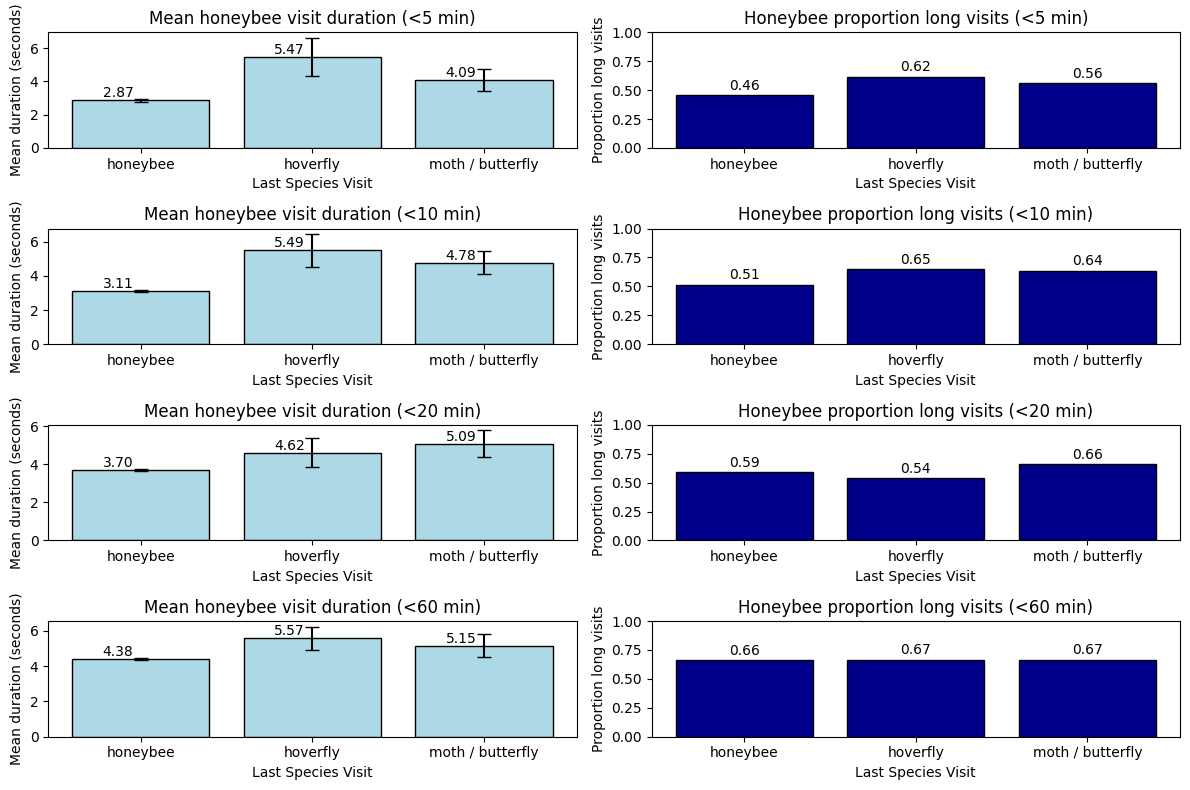

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#time interavals and species to insepct
time_intervals = [5, 10, 20, 60]
species_list = ['honeybee', 'hoverfly', 'moth / butterfly']
results = []

#setup plotting
fig, axes = plt.subplots(len(time_intervals), 2, figsize=(12, 2 * len(time_intervals)))


#loop
for i, time_window in enumerate(time_intervals): # Loop through time intervals (x minutes after visit
    #filter data by time interval AND species
    filtered_df = merged_df.query(
        f'time_since_last_minutes < {time_window} and species == "honeybee" and last_species_visit != "wasp"'
    )
    #Resolving naming issue within dataset
    filtered_df['species'] = filtered_df['species'].map(lambda x: x.replace('moth', 'moth / butterfly'))
    filtered_df['last_species_visit'] = filtered_df['last_species_visit'].map(lambda x: x.replace('moth', 'moth / butterfly'))
   
    groups = filtered_df.groupby('last_species_visit')# Group the last species to visit (response species is honeybee)

    # skip empty cases safely
    if len(groups) == 0:
        continue
        
    #calculate statistics
    grouped_stats = groups[['time', 'succesful']].agg(['mean', 'std', 'count']).reset_index()
    species = grouped_stats['last_species_visit']

    time_means = grouped_stats[('time', 'mean')]
    time_stds = grouped_stats[('time', 'std')]
    time_counts = grouped_stats[('time', 'count')]

    success_means = grouped_stats[('succesful', 'mean')]
    success_stds = grouped_stats[('succesful', 'std')]
    success_counts = grouped_stats[('succesful', 'count')]

    #for all of the combinations calculate p-value, cohens d and update into results list
    for sp1, sp2 in combinations(species_list, 2):
        if sp1 not in groups.groups or sp2 not in groups.groups:
            continue

        group1 = groups.get_group(sp1)['time'].dropna()
        group2 = groups.get_group(sp2)['time'].dropna()

        if len(group1) < 2 or len(group2) < 2:
            continue

        # Welch t-test
        t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)

        # Effect size
        d = cohens_d(group1, group2)

        results.append({
            "time_window": time_window,
            "comparison": f"{sp1} vs {sp2}",
            "mean_diff": group1.mean() - group2.mean(),
            "cohens_d": d,
            "p_value": p_val
        })

#plot the outputs

    ax1 = axes[i, 0]
    ax2 = axes[i, 1]

    bars1 = ax1.bar(
        species,
        time_means,
        yerr=time_stds / np.sqrt(time_counts),
        capsize=5,
        color='lightblue',
        edgecolor='black'
    )

    ax1.set_xlabel('Last Species Visit')
    ax1.set_ylabel('Mean duration (seconds)')
    ax1.set_title(f'Mean honeybee visit duration (<{time_window} min)')

    for bar, mean in zip(bars1, time_means):
        ax1.text(
            bar.get_x() + bar.get_width() / 3,
            bar.get_height(),
            f'{mean:.2f}',
            ha='center',
            va='bottom'
        )
#Plot for proportion succesful.

    bars2 = ax2.bar(
        species,
        success_means,
        color='darkblue',
        edgecolor='black'
    )

    ax2.set_xlabel('Last Species Visit')
    ax2.set_ylabel('Proportion long visits')
    ax2.set_ylim([0, 1])
    ax2.set_title(f'Honeybee proportion long visits (<{time_window} min)')

    for bar, mean in zip(bars2, success_means):
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f'{mean:.2f}',
            ha='center',
            va='bottom'
        )

#graph outputs
plt.tight_layout()
plt.savefig('plot_outputs/interspesific_visitation_patterns.jpg', dpi=300)
plt.show()

#Effects size table
results_df = pd.DataFrame(results)

#save
results_df.to_csv(
    "plot_outputs/interspesific_effect_sizes.csv",
    index=False
)

In [22]:
results_df

,time_window,comparison,mean_diff,cohens_d,p_value
0,5,honeybee vs hoverfly,-2.595552,-0.946642,0.044049
1,5,honeybee vs moth / butterfly,-1.218321,-0.445984,0.070561
2,5,hoverfly vs moth / butterfly,1.377231,0.388752,0.308515
3,10,honeybee vs hoverfly,-2.383120,-0.882572,0.023299
4,10,honeybee vs moth / butterfly,-1.664760,-0.612509,0.021500
5,10,hoverfly vs moth / butterfly,0.718360,0.182817,0.543634
6,20,honeybee vs hoverfly,-0.917319,-0.304587,0.251039
7,20,honeybee vs moth / butterfly,-1.393336,-0.458807,0.053301
8,20,hoverfly vs moth / butterfly,-0.476016,-0.112439,0.650007
9,60,honeybee vs hoverfly,-1.185676,-0.355245,0.085728


### Appendix 5B Sensitivity Analysis

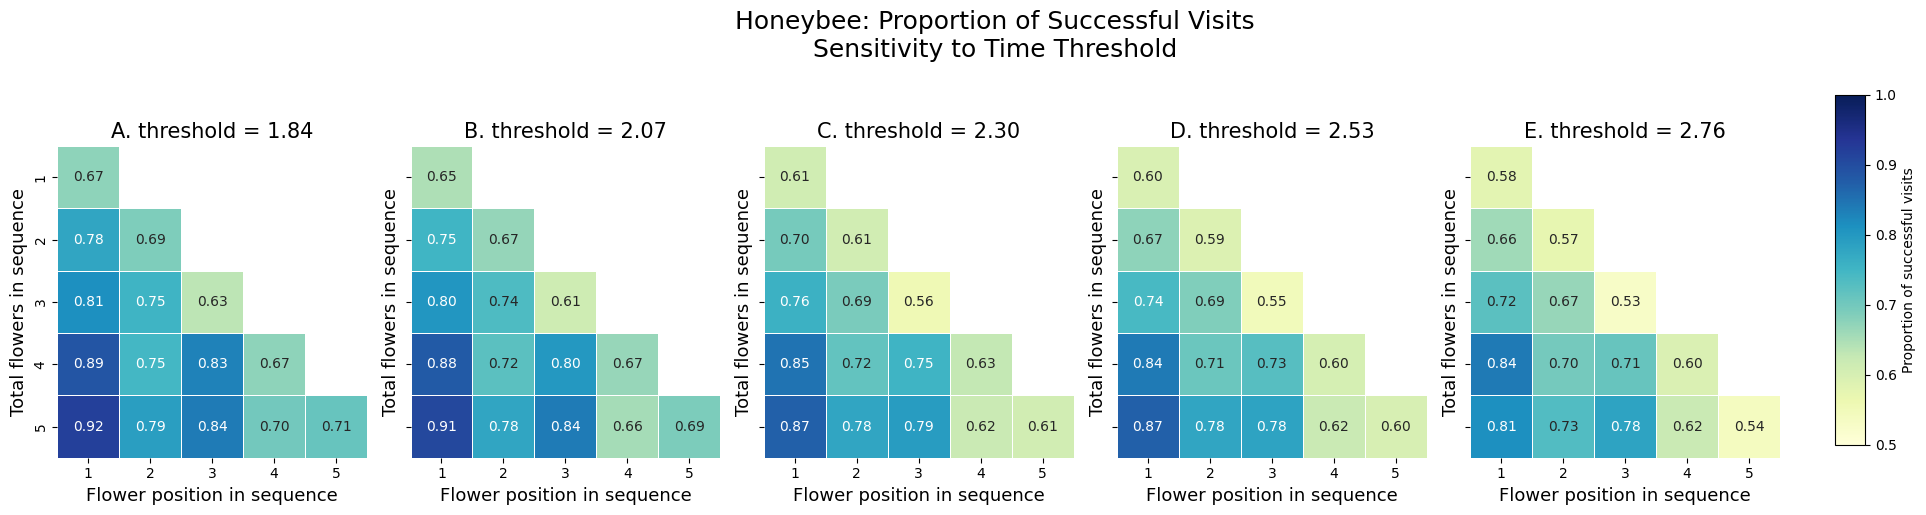

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

#settings
meanval = 2.3           
analysis = [meanval * 0.8, meanval * 0.9, meanval, meanval * 1.1, meanval * 1.2]

# Only honeybee
group = {
    'species': 'honeybee',
    'max_seq_filter': 6,
    'title': 'Honeybee (sequences with < 6 flowers)'
}

#figure settings
fig, axes = plt.subplots(
    1, 5,
    figsize=(4 * 5, 5),       
    sharex=True,
    sharey=True,
    squeeze=False
)

plt.subplots_adjust(hspace=0.4, wspace=0.08)

# Font sizes
f = 13
f2 = 15

prop_df = merged_df.copy() # useing prop_df for this

# Filter once (honeybee only)
clean = prop_df[
    (prop_df['species'] == 'honeybee') &
    (prop_df['max_seq'] < group['max_seq_filter'])
]

for col_idx, threshold in enumerate(analysis):
    ax = axes[0, col_idx]
# apply threshold
    success_col = clean['time'] > threshold
    data = (
        clean
        .assign(successful=success_col)
        .groupby(['max_seq', 'visit_sequence'])['successful']
        .agg(['mean', 'count'])
        .reset_index()
    )

    # Pivot to heatmap shape
    pivot = data.pivot(
        index='max_seq',
        columns='visit_sequence',
        values='mean'
    )

    # Heatmap
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        linewidths=0.6,
        linecolor='white',
        cbar=False,                # we'll add one shared below
        ax=ax,
        vmin=0.5,
        vmax=1                     # crucial for fair comparison across thresholds
    )

    # Labelsn
    ax.set_xlabel("Flower position in sequence", fontsize=f)
    ax.set_ylabel("Total flowers in sequence", fontsize=f)
    ax.set_title(f"{chr(65+col_idx)}. threshold = {threshold:.2f}", fontsize=f2)

# One shared colorbar on the right
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(axes[0,0].collections[0], cax=cbar_ax, label="Proportion of successful visits")

fig.suptitle("Honeybee: Proportion of Successful Visits\nSensitivity to Time Threshold", fontsize=18, y=1.02)

plt.tight_layout(rect=[0, 0, 0.90, 0.96])  # leave space for colorbar
plt.show()

In [24]:
merged_df.head()

,Unnamed: 0,track,species,flower,flower_code,visit_num,time,movement,data_point,clock_time,...,time_since_last_visit,last_species_visit,last_visit_time,time_last_of_same_species,time_since_last_minutes,clock_time_minutes,flower_visit_num,max_seq,succesful,Cluster
3,3,10912132300,honeybee,4.0,10904.0,1.0,1.1,32.5,1,44003,...,NaN,NaN,NaN,NaN,NaN,733.383333,1,2,False,0.0
4,4,10912132300,honeybee,5.0,10905.0,1.0,0.8,45.3,1,44003,...,NaN,NaN,NaN,NaN,NaN,733.383333,1,2,False,NaN
5,5,10912240800,honeybee,0.0,10900.0,1.0,10.3,109.9,1,44648,...,NaN,NaN,NaN,NaN,NaN,744.133333,1,1,True,0.0
7,7,10912323000,honeybee,4.0,10904.0,1.0,3.8,60.4,1,45150,...,1147.0,honeybee,1.1,1147.0,19.116667,752.500000,2,1,True,0.0
8,8,10912365000,honeybee,4.0,10904.0,1.0,1.3,42.5,1,45410,...,260.0,honeybee,3.8,260.0,4.333333,756.833333,3,5,False,0.0


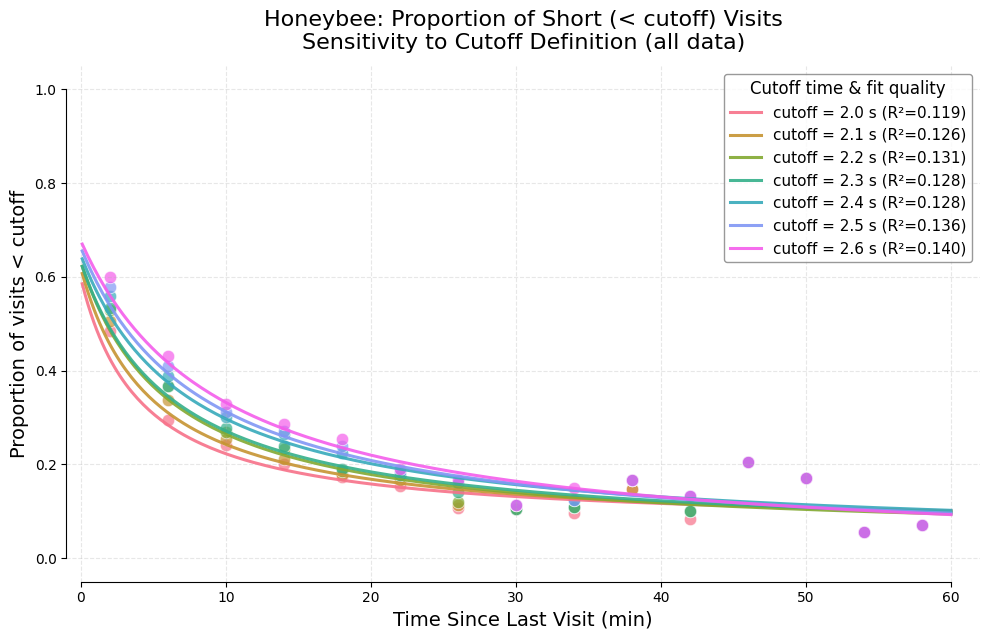

   cutoff      a      b      c     R2
0   1.955  2.210  4.163  0.067  0.119
1   2.070  2.769  4.938  0.057  0.126
2   2.185  3.649  6.152  0.039  0.131
3   2.300  3.774  6.394  0.041  0.128
4   2.415  4.625  7.549  0.034  0.128
5   2.530  5.474  8.468  0.016  0.136
6   2.645  6.558  9.674 -0.001  0.140


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

# ────────────────────────────────────────────────
# Settings
# ────────────────────────────────────────────────
max_graph = 60
val = 'time_since_last_minutes'          # x-variable
base_cutoff = 2.3                           # original threshold

# Sensitivity: test several cutoffs around the base value
cutoffs = [meanval*0.85, meanval * 0.9, meanval*0.95, meanval, meanval * 1.05, meanval * 1.1, meanval*1.15]

colors = sns.color_palette("husl", len(cutoffs))   # nice distinct colors

# Filter once — only honeybee "all" data
mdf = merged_df[
    (merged_df['species'] == 'honeybee') &
    (merged_df[val] < max_graph) &
    (merged_df['time'] < 20)
].copy()

if mdf.empty:
    print("No data after filtering")
else:
    fig, ax = plt.subplots(figsize=(10, 6.5))

    results = []

    for cutoff, color in zip(cutoffs, colors):
        # Binary outcome for this cutoff
        y_raw = (mdf['time'] < cutoff).astype(float).values
        x_raw = mdf[val].values

        # Try to fit inverse function y = a / (x + b) + c
        try:
            popt, _ = curve_fit(
                lambda x, a, b, c: a / (x + b) + c,
                x_raw, y_raw,
                p0=[1.0, 1.0, 0.0],          # reasonable starting guess
                bounds=([0, 0, -0.5], [np.inf, np.inf, 1.5]),
                maxfev=2000
            )
            a, b, c = popt

            # R²
            y_pred = a / (x_raw + b) + c
            ss_res = np.sum((y_raw - y_pred)**2)
            ss_tot = np.sum((y_raw - np.mean(y_raw))**2)
            r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

            results.append({'cutoff': cutoff, 'a': a, 'b': b, 'c': c, 'R2': r2})

            # Fit line
            x_fit = np.linspace(0.1, max_graph, 300)
            y_fit = a / (x_fit + b) + c
            ax.plot(x_fit, y_fit, color=color, lw=2.2, alpha=0.9,
                    label=f"cutoff = {cutoff:.1f} s (R²={r2:.3f})")

        except (RuntimeError, ValueError):
            # If fit fails, still show scatter
            results.append({'cutoff': cutoff, 'a': np.nan, 'b': np.nan, 'c': np.nan, 'R2': np.nan})

        # Binned scatter 
        mdf[f'under_cutoff'] = mdf['time'] < cutoff
        mdf['time_bin'] = pd.cut(mdf[val], bins=range(0, max_graph + 4, 4), right=False)
        binned = (
            mdf.groupby('time_bin')[f'under_cutoff']
            .agg(['mean', 'count'])
            .reset_index()
            .rename(columns={'mean': 'proportion', 'count': 'n'})
        )
        binned['time_mid'] = binned['time_bin'].apply(lambda x: x.mid)

        # Scatter: semi-transparent 
        ax.scatter(binned['time_mid'], binned['proportion'],
                   s=80, color=color, alpha=0.7, edgecolor='w', linewidth=0.6)

    # settings for graph
    ax.set_xlim(-1, max_graph + 2)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Time Since Last Visit (min)", fontsize=14)
    ax.set_ylabel("Proportion of visits < cutoff", fontsize=14)
    ax.set_title("Honeybee: Proportion of Short (< cutoff) Visits\n"
                 "Sensitivity to Cutoff Definition (all data)",
                 fontsize=16, pad=12)

    ax.legend(loc='upper right', fontsize=11, frameon=True, edgecolor='gray',
              title="Cutoff time & fit quality", title_fontsize=12)

    ax.grid(True, alpha=0.3, linestyle='--')
    sns.despine(ax=ax, trim=True)

    plt.tight_layout()
    plt.savefig("plot_outputs/honeybee_proportion_sensitivity_all.png", dpi=300, bbox_inches='tight')
    plt.show()

    # print fit for each parameters
    print(pd.DataFrame(results).round(3))

In [26]:
res = pd.DataFrame(results)
base = res[res['cutoff'] == 2.30].iloc[0]

# Add columns - calculating percentage and absolute difference for value in sensitivity analysis
res['Δa (%)'] = ((res['a'] - base['a']) / base['a'] * 100).round(1)
res['Δb (%)'] = ((res['b'] - base['b']) / base['b'] * 100).round(1)
res['Δc (%)'] = ((res['c'] - base['c']) / base['c'] * 100).round(1)
res['Δa (abs)'] = (res['a'] - base['a']).round(3)
res['Δb (abs)'] = (res['b'] - base['b']).round(3)
res['Δc (abs)'] = (res['c'] - base['c']).round(3)
res['percentage_change'] = ['-15', '-10', '-5', '0', '5', '10', '15']
res['mean_percentage_change'] = res.apply(
    lambda x: np.mean([
        abs(x['Δb (%)']),
        abs(x['Δc (%)']),
        abs(x['Δa (%)'])
    ]),
    axis=1
)
# Print nice table (or save to csv: df.to_csv('sensitivity.csv', index=False))
print(res[['percentage_change','cutoff', 'a', 'b', 'c', 'Δa (%)', 'Δb (%)', 'Δc (%)', 'mean_percentage_change']].to_string(index=False))

percentage_change  cutoff        a        b         c  Δa (%)  Δb (%)  Δc (%)  mean_percentage_change
              -15   1.955 2.210175 4.162783  0.066914   -41.4   -34.9    62.3               46.200000
              -10   2.070 2.769435 4.937850  0.057439   -26.6   -22.8    39.4               29.600000
               -5   2.185 3.648752 6.151766  0.039086    -3.3    -3.8    -5.2                4.100000
                0   2.300 3.774140 6.394445  0.041219     0.0     0.0     0.0                0.000000
                5   2.415 4.625190 7.548927  0.033789    22.5    18.1   -18.0               19.533333
               10   2.530 5.473880 8.467959  0.016353    45.0    32.4   -60.3               45.900000
               15   2.645 6.557687 9.673854 -0.001022    73.8    51.3  -102.5               75.866667


In [28]:
res[['percentage_change','cutoff', 'a', 'b', 'c', 'Δa (%)', 'Δb (%)', 'Δc (%)', 'mean_percentage_change']].round(2)

,percentage_change,cutoff,a,b,c,Δa (%),Δb (%),Δc (%),mean_percentage_change
0,-15,1.95,2.21,4.16,0.07,-41.4,-34.9,62.3,46.20
1,-10,2.07,2.77,4.94,0.06,-26.6,-22.8,39.4,29.60
2,-5,2.18,3.65,6.15,0.04,-3.3,-3.8,-5.2,4.10
3,0,2.30,3.77,6.39,0.04,0.0,0.0,0.0,0.00
4,5,2.42,4.63,7.55,0.03,22.5,18.1,-18.0,19.53
5,10,2.53,5.47,8.47,0.02,45.0,32.4,-60.3,45.90
6,15,2.64,6.56,9.67,-0.00,73.8,51.3,-102.5,75.87
